##  Setup & Load Data

### 📦 ติดตั้งและ Import Libraries

ก่อนเริ่มต้น เราต้อง import library ที่จำเป็นสำหรับการวิเคราะห์ข้อมูลและสร้างกราฟ โดย `pandas` ใช้สำหรับจัดการตาราง, `numpy` สำหรับคำนวณเชิงตัวเลข, `matplotlib` และ `seaborn` สำหรับสร้าง static chart, `plotly` สำหรับ interactive visualization และ `warnings` เพื่อซ่อน warning ที่ไม่จำเป็น การเตรียม environment ที่ดีตั้งแต่ต้นจะช่วยให้ workflow ราบรื่นตลอดทั้ง notebook

In [ ]:
# ติดตั้ง library เพิ่มเติม (ถ้าจำเป็น)
!pip install plotly kaleido -q

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

#ดาวน์โหลดฟอนต์ภาษาไทย (TH Sarabun New)
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
#เพิ่มฟอนต์เข้าไปในระบบ
mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')
mpl.rc('font', family='TH Sarabun New', size=16)
sns.set_theme(style="whitegrid", font="TH Sarabun New")

# ตั้งค่า style
plt.rcParams['figure.dpi'] = 120

print('✅ Import สำเร็จ! พร้อมวิเคราะห์ข้อมูลแล้ว 🚀')

✅ Import สำเร็จ! พร้อมวิเคราะห์ข้อมูลแล้ว 🚀


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_case = pd.read_csv('/content/drive/MyDrive/dataset hack1/ข้อมูลการแจ้งเหตุความรุนแรงในครอบครัว.csv')
df_offender = pd.read_csv('/content/drive/MyDrive/dataset hack1/ข้อมูลผู้กระทำความรุนแรงในครอบครัว.csv')
df_victim = pd.read_csv('/content/drive/MyDrive/dataset hack1/ข้อมูลผู้ถูกกระทำความรุนแรงในครอบครัว.csv')

#print('=' * 60)
print('ข้อมูลการแจ้งเหตุความรุนแรงในครอบครัว')
print(f'   ➜ จำนวนแถว: {df_case.shape[0]:,} แถว | คอลัมน์: {df_case.shape[1]} คอลัมน์')
print(f'   ➜ คอลัมน์: {df_case.columns.tolist()}')
print()
print('ข้อมูลผู้กระทำความรุนแรงในครอบครัว')
print(f'   ➜ จำนวนแถว: {df_offender.shape[0]:,} แถว | คอลัมน์: {df_offender.shape[1]} คอลัมน์')
print(f'   ➜ คอลัมน์: {df_offender.columns.tolist()}')

print('ข้อมูลผู้ถูกกระทำความรุนแรงในครอบครัว')
print(f'   ➜ จำนวนแถว: {df_victim.shape[0]:,} แถว | คอลัมน์: {df_victim.shape[1]} คอลัมน์')
print(f'   ➜ คอลัมน์: {df_victim.columns.tolist()}')
#print('=' * 60)

print('🔍 ตัวอย่างข้อมูลการแจ้งเหตุความรุนแรงในครอบครัว:')
display(df_case.sample(3))

print('🔍 ตัวอย่างข้อมูลผู้กระทำความรุนแรงในครอบครัว:')
display(df_offender.sample(3))

print('🔍 ตัวอย่างข้อมูลผู้ถูกกระทำความรุนแรงในครอบครัว:')
display(df_offender.sample(3))

ข้อมูลการแจ้งเหตุความรุนแรงในครอบครัว
   ➜ จำนวนแถว: 877 แถว | คอลัมน์: 11 คอลัมน์
   ➜ คอลัมน์: ['Regional', 'Province', 'District', 'Sub-District', 'Derivation', 'Source', 'Source Type', 'Other Source Type', 'Channel', 'Period', 'Locale']

ข้อมูลผู้กระทำความรุนแรงในครอบครัว
   ➜ จำนวนแถว: 564 แถว | คอลัมน์: 19 คอลัมน์
   ➜ คอลัมน์: ['Regional', 'Province', 'District', 'Sub-District', 'Gender', 'Age', 'Age Range', 'Relation', 'Mariage Registration', 'Alcohol', 'Drug', 'Authoritative', 'Rage', 'Jealous', 'Divorce', 'Health Problem', 'Mental Problem', 'Gambling Addict', 'Economics Stress']
ข้อมูลผู้ถูกกระทำความรุนแรงในครอบครัว
   ➜ จำนวนแถว: 597 แถว | คอลัมน์: 20 คอลัมน์
   ➜ คอลัมน์: ['Regional', 'Province', 'District', 'Sub-District', 'Gender', 'Age', 'Age Range', 'Relation', 'Mariage Registration', 'Alcohol', 'Drug', 'Authoritative', 'Rage', 'Jealous', 'Divorce', 'Health Problem', 'Mental Problem', 'Gambling Addict', 'Economics Stress', 'Relation Type']
🔍 ตัวอย่างข้อมูลการแจ้งเหตุควา

,Regional,Province,District,Sub-District,Derivation,Source,Source Type,Other Source Type,Channel,Period,Locale
249,ภาคกลาง,ระยอง,เมืองระยอง,ปากน้ำ,VCIS (Incident ถูกสร้างจากระบบ VCIS),บุคคล,ผู้รับทราบเหตุการณ์และนำมาแจ้งต่อ,ไม่ระบุ,ข่าว,18:01 – 00:00,สถานที่ส่วนบุคคล
456,ภาคตะวันออกเฉียงเหนือ,บุรีรัมย์,สตึก,นิคม,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สำนักข่าว,ไม่ระบุ,ข่าว,12:01 – 18:00,สถานที่ส่วนบุคคล
591,ภาคเหนือ,กำแพงเพชร,ไทรงาม,หนองคล้า,VCIS (Incident ถูกสร้างจากระบบ VCIS),บุคคล,ผู้รับทราบเหตุการณ์และนำมาแจ้งต่อ,ไม่ระบุ,โทรศัพท์,18:01 – 00:00,สถานที่ส่วนบุคคล


🔍 ตัวอย่างข้อมูลผู้กระทำความรุนแรงในครอบครัว:


,Regional,Province,District,Sub-District,Gender,Age,Age Range,Relation,Mariage Registration,Alcohol,Drug,Authoritative,Rage,Jealous,Divorce,Health Problem,Mental Problem,Gambling Addict,Economics Stress
36,ภาคกลาง,กรุงเทพมหานคร,เขตประเวศ,ประเวศ,ชาย,68,วัยสูงอายุ 60 ปีขึ้นไป,โสด,ไม่ระบุ,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่
518,ภาคใต้,นราธิวาส,ศรีสาคร,ศรีบรรพต,ชาย,41,วัยกลางคน 36 - 59 ปี,สมรส,จดทะเบียนสมรสแล้ว,ไม่,ใช่,ใช่,ไม่,ใช่,ไม่,ไม่,ใช่,ไม่,ใช่
7,ภาคกลาง,กรุงเทพมหานคร,เขตคลองสามวา,บางชัน,ชาย,42,วัยกลางคน 36 - 59 ปี,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่


🔍 ตัวอย่างข้อมูลผู้ถูกกระทำความรุนแรงในครอบครัว:


,Regional,Province,District,Sub-District,Gender,Age,Age Range,Relation,Mariage Registration,Alcohol,Drug,Authoritative,Rage,Jealous,Divorce,Health Problem,Mental Problem,Gambling Addict,Economics Stress
143,ภาคกลาง,ระยอง,บ้านค่าย,หนองบัว,ชาย,34,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,โสด,ไม่ระบุ,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่
308,ภาคตะวันออกเฉียงเหนือ,บึงกาฬ,โซ่พิสัย,หนองพันทา,ชาย,48,วัยกลางคน 36 - 59 ปี,สมรส,ยังไม่ได้จดทะเบียนสมรส,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่
483,ภาคเหนือ,เชียงราย,ป่าแดด,ป่าแงะ,ชาย,40,วัยกลางคน 36 - 59 ปี,โสด,ไม่ระบุ,ใช่,ใช่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ใช่


---
##  **First Look — EDA เบื้องต้น**

### 📊 ภาพรวมสถิติเบื้องต้น

ขั้นตอน Exploratory Data Analysis (EDA) เบื้องต้น คือการสำรวจข้อมูลอย่างรวดเร็วเพื่อให้เข้าใจ "รูปร่าง" ของ dataset ก่อนลงลึก เราดูสถิติพื้นฐาน (`describe()`), จำนวนค่า null, ค่า unique ในแต่ละคอลัมน์ และยอดนักศึกษารวม ข้อมูลเหล่านี้ช่วยให้ตั้งสมมติฐานได้ว่าข้อมูลมีปัญหาอะไร และควรโฟกัสวิเคราะห์ตรงไหน

In [ ]:
df_case.info()
df_offender.info()
df_victim.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 877 entries, 0 to 876
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Regional           877 non-null    object
 1   Province           877 non-null    object
 2   District           877 non-null    object
 3   Sub-District       877 non-null    object
 4   Derivation         877 non-null    object
 5   Source             877 non-null    object
 6   Source Type        877 non-null    object
 7   Other Source Type  877 non-null    object
 8   Channel            877 non-null    object
 9   Period             877 non-null    object
 10  Locale             877 non-null    object
dtypes: object(11)
memory usage: 75.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564 entries, 0 to 563
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Regional              564 non-nu

In [ ]:
describe_case=df_case.describe()
describe_offender=df_offender.describe()
describe_victim=df_victim.describe()

print(describe_case)
print(describe_offender)
print(describe_case)

       Regional       Province      District Sub-District  \
count       877            877           877          877   
unique        4             74           410          664   
top     ภาคกลาง  กรุงเทพมหานคร  เมืองราชบุรี      ในเมือง   
freq        382             95            14           17   

                                  Derivation    Source   Source Type  \
count                                    877       877           877   
unique                                     2         2            17   
top     VCIS (Incident ถูกสร้างจากระบบ VCIS)  หน่วยงาน  สายด่วน 1300   
freq                                     869       657           260   

       Other Source Type   Channel         Period            Locale  
count                877       877            877               877  
unique                53         6              4                 4  
top              ไม่ระบุ  โทรศัพท์  12:01 – 18:00  สถานที่ส่วนบุคคล  
freq                 816       302            317    

In [ ]:
import pandas as pd

# สร้าง Dictionary เพื่อวนลูปเช็กทุก Dataset
datasets = {
    "CASE (เหตุการณ์)": df_case,
    "OFFENDER (ผู้กระทำ)": df_offender,
    "VICTIM (ผู้ถูกกระทำ)": df_victim
}

print("🔎 รายงานการตรวจสอบข้อมูลซ้ำ (Duplicate Detection Report)\n")

for name, df in datasets.items():
    # หาแถวที่ซ้ำกัน (ใช้ keep=False เพื่อให้แสดงทุกแถวที่มีคู่ซ้ำ จะได้เห็นตัวที่หน้าตาเหมือนกันชัดๆ)
    duplicates = df[df.duplicated(keep=False)]

    print(f"--- {name} ---")
    print(f"📊 จำนวนแถวทั้งหมดก่อนคลีน: {len(df):,} แถว")
    print(f"👯 พบแถวที่มีข้อมูลซ้ำกัน: {len(duplicates):,} แถว")

    if len(duplicates) > 0:
        print(f"📌 ตัวอย่างข้อมูลที่ซ้ำกัน (2 คู่แรก):")
        # แสดงตัวอย่าง 4 แถวแรกที่ซ้ำกัน (มักจะแสดงเป็นคู่ๆ ที่เหมือนกัน)
        display(duplicates.head(4))
    else:
        print("✅ ไม่พบข้อมูลซ้ำ")

    print("-" * 50)

# สรุปภาพรวมความต่าง
print("\n💡 สรุปความต่างหลังลบข้อมูลซ้ำ:")
for name, df in datasets.items():
    clean_count = len(df.drop_duplicates())
    diff = len(df) - clean_count
    print(f"✅ {name}: ข้อมูลจะลดลง {diff} แถว (จาก {len(df)} เหลือ {clean_count})")

🔎 รายงานการตรวจสอบข้อมูลซ้ำ (Duplicate Detection Report)

--- CASE (เหตุการณ์) ---
📊 จำนวนแถวทั้งหมดก่อนคลีน: 877 แถว
👯 พบแถวที่มีข้อมูลซ้ำกัน: 31 แถว
📌 ตัวอย่างข้อมูลที่ซ้ำกัน (2 คู่แรก):


,Regional,Province,District,Sub-District,Derivation,Source,Source Type,Other Source Type,Channel,Period,Locale
13,ภาคกลาง,กรุงเทพมหานคร,เขตทุ่งครุ,บางมด,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,ระบบ,06:01 – 12:00,สถานที่ส่วนบุคคล
50,ภาคกลาง,กรุงเทพมหานคร,เขตวัฒนา,คลองตันเหนือ,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,โทรศัพท์,18:01 – 00:00,สถานที่ส่วนบุคคล
62,ภาคกลาง,กรุงเทพมหานคร,เขตวัฒนา,คลองตันเหนือ,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,โทรศัพท์,18:01 – 00:00,สถานที่ส่วนบุคคล
87,ภาคกลาง,กรุงเทพมหานคร,เขตทุ่งครุ,บางมด,VCIS (Incident ถูกสร้างจากระบบ VCIS),หน่วยงาน,สายด่วน 1300,ไม่ระบุ,ระบบ,06:01 – 12:00,สถานที่ส่วนบุคคล


--------------------------------------------------
--- OFFENDER (ผู้กระทำ) ---
📊 จำนวนแถวทั้งหมดก่อนคลีน: 564 แถว
👯 พบแถวที่มีข้อมูลซ้ำกัน: 22 แถว
📌 ตัวอย่างข้อมูลที่ซ้ำกัน (2 คู่แรก):


,Regional,Province,District,Sub-District,Gender,Age,Age Range,Relation,Mariage Registration,Alcohol,Drug,Authoritative,Rage,Jealous,Divorce,Health Problem,Mental Problem,Gambling Addict,Economics Stress
10,ภาคกลาง,กรุงเทพมหานคร,เขตทุ่งครุ,บางมด,ชาย,22,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,แยกกันอยู่,ยังไม่ได้จดทะเบียนหย่า,ไม่,ไม่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่
14,ภาคกลาง,กรุงเทพมหานคร,เขตภาษีเจริญ,บางหว้า,ชาย,48,วัยกลางคน 36 - 59 ปี,สมรส,ยังไม่ได้จดทะเบียนสมรส,ใช่,ไม่,ใช่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่
28,ภาคกลาง,กรุงเทพมหานคร,เขตภาษีเจริญ,บางหว้า,ชาย,48,วัยกลางคน 36 - 59 ปี,สมรส,ยังไม่ได้จดทะเบียนสมรส,ใช่,ไม่,ใช่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่
56,ภาคกลาง,กรุงเทพมหานคร,เขตทุ่งครุ,บางมด,ชาย,22,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,แยกกันอยู่,ยังไม่ได้จดทะเบียนหย่า,ไม่,ไม่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่


--------------------------------------------------
--- VICTIM (ผู้ถูกกระทำ) ---
📊 จำนวนแถวทั้งหมดก่อนคลีน: 597 แถว
👯 พบแถวที่มีข้อมูลซ้ำกัน: 20 แถว
📌 ตัวอย่างข้อมูลที่ซ้ำกัน (2 คู่แรก):


,Regional,Province,District,Sub-District,Gender,Age,Age Range,Relation,Mariage Registration,Alcohol,Drug,Authoritative,Rage,Jealous,Divorce,Health Problem,Mental Problem,Gambling Addict,Economics Stress,Relation Type
10,ภาคกลาง,กรุงเทพมหานคร,เขตทุ่งครุ,บางมด,หญิง,32,วัยผู้ใหญ่ตอนต้น 19 - 35 ปี,แยกกันอยู่,ยังไม่ได้จดทะเบียนหย่า,ไม่,ไม่,ไม่,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,"คู่ชีวิต,อดีตสามี"
14,ภาคกลาง,กรุงเทพมหานคร,เขตภาษีเจริญ,บางหว้า,หญิง,54,วัยกลางคน 36 - 59 ปี,สมรส,ยังไม่ได้จดทะเบียนสมรส,ใช่,ไม่,ใช่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,"คู่ชีวิต,สามี"
29,ภาคกลาง,กรุงเทพมหานคร,เขตภาษีเจริญ,บางหว้า,หญิง,54,วัยกลางคน 36 - 59 ปี,สมรส,ยังไม่ได้จดทะเบียนสมรส,ใช่,ไม่,ใช่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,"คู่ชีวิต,สามี"
39,ภาคกลาง,กรุงเทพมหานคร,เขตคลองเตย,คลองเตย,ชาย,83,วัยสูงอายุ 60 ปีขึ้นไป,สมรส,จดทะเบียนสมรสแล้ว,ไม่,ไม่,ใช่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,ไม่,"คู่ชีวิต,ภรรยา"


--------------------------------------------------

💡 สรุปความต่างหลังลบข้อมูลซ้ำ:
✅ CASE (เหตุการณ์): ข้อมูลจะลดลง 16 แถว (จาก 877 เหลือ 861)
✅ OFFENDER (ผู้กระทำ): ข้อมูลจะลดลง 11 แถว (จาก 564 เหลือ 553)
✅ VICTIM (ผู้ถูกกระทำ): ข้อมูลจะลดลง 10 แถว (จาก 597 เหลือ 587)


In [ ]:
import pandas as pd

# 1. ประกาศตัวแปรเก็บ Log ไว้ด้านนอกสุด (ถูกแล้ว)
cleaning_log = []

# (อย่าลืมประกาศ datasets ถ้ายังไม่ได้ทำใน Cell เดียวกัน)
datasets = {
    "CASE (เหตุการณ์)": df_case,
    "OFFENDER (ผู้กระทำ)": df_offender,
    "VICTIM (ผู้ถูกกระทำ)": df_victim
}

for name, df in datasets.items():
    print("="*60)
    print(f"📊 DATASET: {name}")

    # สถิติพื้นฐาน
    rows, cols = df.shape
    null_count = df.isnull().sum().sum()
    dup_count = df.duplicated().sum()

    print(f" 📄 จำนวนแถว: {rows:,} | คอลัมน์: {cols} | Missing: {null_count:,}")
    print(f" 👯 ข้อมูลซ้ำ (Duplicate): {dup_count}")

    # 2. ตรวจสอบรายคอลัมน์ (Unique & Type)
    # แก้ไข: ใช้ str(dtype) เพื่อป้องกัน TypeError: ObjectDType.__format__
    print("\n [Column Inspection]")
    for col in df.columns:
        dtype = df[col].dtype
        unique_val = df[col].nunique()
        print(f" 🔹 {col:<20} | Type: {str(dtype):<10} | Unique: {unique_val}")

    # 3. ตรวจสอบความผิดปกติของข้อมูล (Logic Check)
    if 'Age' in df.columns:
        # เช็กค่าที่ไม่ใช่ตัวเลข
        age_issues = pd.to_numeric(df['Age'], errors='coerce').isna().sum() - df['Age'].isna().sum()
        if age_issues > 0:
            cleaning_log.append(f"[{name}] พบค่าในคอลัมน์ Age ไม่เป็นตัวเลข {age_issues} รายการ")

        # เช็กค่าที่ดูเป็นไปไม่ได้ (เช่น อายุ > 120 หรือ < 0)
        outliers = df[(df['Age'] > 120) | (df['Age'] < 0)].shape[0]
        if outliers > 0:
            cleaning_log.append(f"[{name}] พบอายุที่อยู่นอกช่วงปกติ (Outliers) {outliers} รายการ")

    # บันทึกข้อมูลซ้ำลง Log
    if dup_count > 0:
        cleaning_log.append(f"[{name}] พบข้อมูลซ้ำ {dup_count} รายการ")

    # บันทึกการจัดการ Noise เรื่องเพศ
    if 'Gender' in df.columns:
        noise_gender = df[df['Gender'] == 'ไม่ระบุเพศ'].shape[0]
        if noise_gender > 0:
            cleaning_log.append(f"[{name}] พบเพศไม่ระบุ {noise_gender} รายการ (ทำการกรองออกในขั้นตอนวิเคราะห์)")

    print()

# --- แสดง Cleaning Log ท้ายสุดเพื่อส่งงานระดับ 4 ---
print("📝 CLEANING LOG".center(60, "="))
if not cleaning_log:
    print("✅ ไม่พบปัญหาข้อมูลที่ต้องแก้ไข")
else:
    for log in cleaning_log:
        print(f"✅ {log}")
print("="*60)

📊 DATASET: CASE (เหตุการณ์)
 📄 จำนวนแถว: 877 | คอลัมน์: 11 | Missing: 0
 👯 ข้อมูลซ้ำ (Duplicate): 16

 [Column Inspection]
 🔹 Regional             | Type: object     | Unique: 4
 🔹 Province             | Type: object     | Unique: 74
 🔹 District             | Type: object     | Unique: 410
 🔹 Sub-District         | Type: object     | Unique: 664
 🔹 Derivation           | Type: object     | Unique: 2
 🔹 Source               | Type: object     | Unique: 2
 🔹 Source Type          | Type: object     | Unique: 17
 🔹 Other Source Type    | Type: object     | Unique: 53
 🔹 Channel              | Type: object     | Unique: 6
 🔹 Period               | Type: object     | Unique: 4
 🔹 Locale               | Type: object     | Unique: 4

📊 DATASET: OFFENDER (ผู้กระทำ)
 📄 จำนวนแถว: 564 | คอลัมน์: 19 | Missing: 0
 👯 ข้อมูลซ้ำ (Duplicate): 11

 [Column Inspection]
 🔹 Regional             | Type: object     | Unique: 4
 🔹 Province             | Type: object     | Unique: 69
 🔹 District             | T

###**1. การจัดการข้อมูลซ้ำซ้อน (Duplicate Data Management)**
จากการตรวจสอบพบรายการข้อมูลที่บันทึกซ้ำซ้อนในทั้ง 3 ชุดข้อมูล (Case, Offender และ Victim) ซึ่งอาจเกิดจากความผิดพลาดในขั้นตอนการบันทึกหรือการส่งข้อมูลเข้าสู่ระบบ คณะผู้จัดทำจึงดำเนินการ ลบข้อมูลที่ซ้ำกันออก (drop_duplicates) เพื่อป้องกันการนับจำนวนเหตุการณ์ที่เกินจริง (Double Counting) และเพื่อให้มั่นใจว่าค่าทางสถิติ เช่น จำนวนเคสรวม และค่าฐานนิยม (Mode) ของอายุ เป็นค่าที่สะท้อนความเป็นจริงมากที่สุด

###**2. การจัดการข้อมูลด้านเพศ (Gender Data Cleaning)**
จากการสำรวจข้อมูลเบื้องต้น พบว่าสัดส่วนของผู้ไม่ระบุเพศมีจำนวนน้อยมากเพียง 0.16% (หรือน้อยกว่า 1%) ของข้อมูลทั้งหมด ซึ่งในทางสถิติถือเป็นสัดส่วนที่ไม่มีนัยสำคัญ (Statistically Insignificant) และไม่ส่งผลต่อการเปลี่ยนแปลงรูปทรงของกราฟหรือผลสรุปภาพรวม
เพื่อให้การวิเคราะห์พฤติกรรมระหว่างเพศชายและเพศหญิงมีความคมชัดและลดสัญญาณรบกวน (Noise) ในการเปรียบเทียบโครงสร้างความเสี่ยง ทางคณะผู้จัดทำจึงตัดสินใจ คัดข้อมูลกลุ่มที่ไม่ระบุเพศออก (Exclude) เฉพาะในส่วนของการทำ Visualization เพื่อมุ่งเน้นไปที่การเปรียบเทียบรูปแบบ (Pattern) ของกลุ่มตัวอย่างหลักได้อย่างชัดเจนที่สุด

In [ ]:
# 1. ลบข้อมูลซ้ำ (Drop Duplicates)
df_case = df_case.drop_duplicates()
df_offender = df_offender.drop_duplicates()
df_victim = df_victim.drop_duplicates()

# 2. กรองเพศที่ไม่ระบุออก (Filter Noise)
df_offender = df_offender[df_offender['Gender'] != 'ไม่ระบุเพศ']
df_victim = df_victim[df_victim['Gender'] != 'ไม่ระบุเพศ']

print("✨ ทำความสะอาดข้อมูลเสร็จสิ้น: ลบข้อมูลซ้ำและกรองเพศที่ไม่เกี่ยวข้องออกแล้ว")

✨ ทำความสะอาดข้อมูลเสร็จสิ้น: ลบข้อมูลซ้ำและกรองเพศที่ไม่เกี่ยวข้องออกแล้ว


In [ ]:
missing_v=df_victim['Gender'].value_counts(dropna=False, normalize=True)
missing_f=df_offender['Gender'].value_counts(dropna=False, normalize=True)

print(f"value missing victim: {missing_v}")
print(f"value missing offender: {missing_f}")

value missing victim: Gender
หญิง    0.803754
ชาย     0.196246
Name: proportion, dtype: float64
value missing offender: Gender
ชาย     0.817029
หญิง    0.182971
Name: proportion, dtype: float64


###**ข้อ 1 — ใครเสี่ยงที่สุด? (Who is at risk?)**
📊 จากข้อมูลเกี่ยวกับ ผู้ถูกกระทำความรุนแรง และ ผู้กระทำความรุนแรงในครอบครัว

จงสร้างกราฟหรือ Visualization ที่ช่วยให้ผู้อ่านสามารถมองเห็นได้อย่างชัดเจนว่า
กลุ่มอายุใด
เพศใด
มี ความเสี่ยงสูงที่สุดในแต่ละบทบาท และรูปแบบความเสี่ยงของ ผู้กระทำและผู้ถูกกระทำมีความแตกต่างกันอย่างไร

Visualization ควรช่วยให้ผู้อ่านสามารถ เปรียบเทียบโครงสร้างของทั้งสองกลุ่มได้ในภาพเดียว และสามารถมองเห็น pattern ของความเสี่ยงได้อย่างชัดเจน

--------------------------------------------------------------------------------
#**กราฟแสดงอายุและเพศว่าผู้ถูกกระทำความรุนแรงและ ผู้กระทำความรุนแรงในครอบครัวอยู่ในช่วงใดมากเป็นพิเศษ**

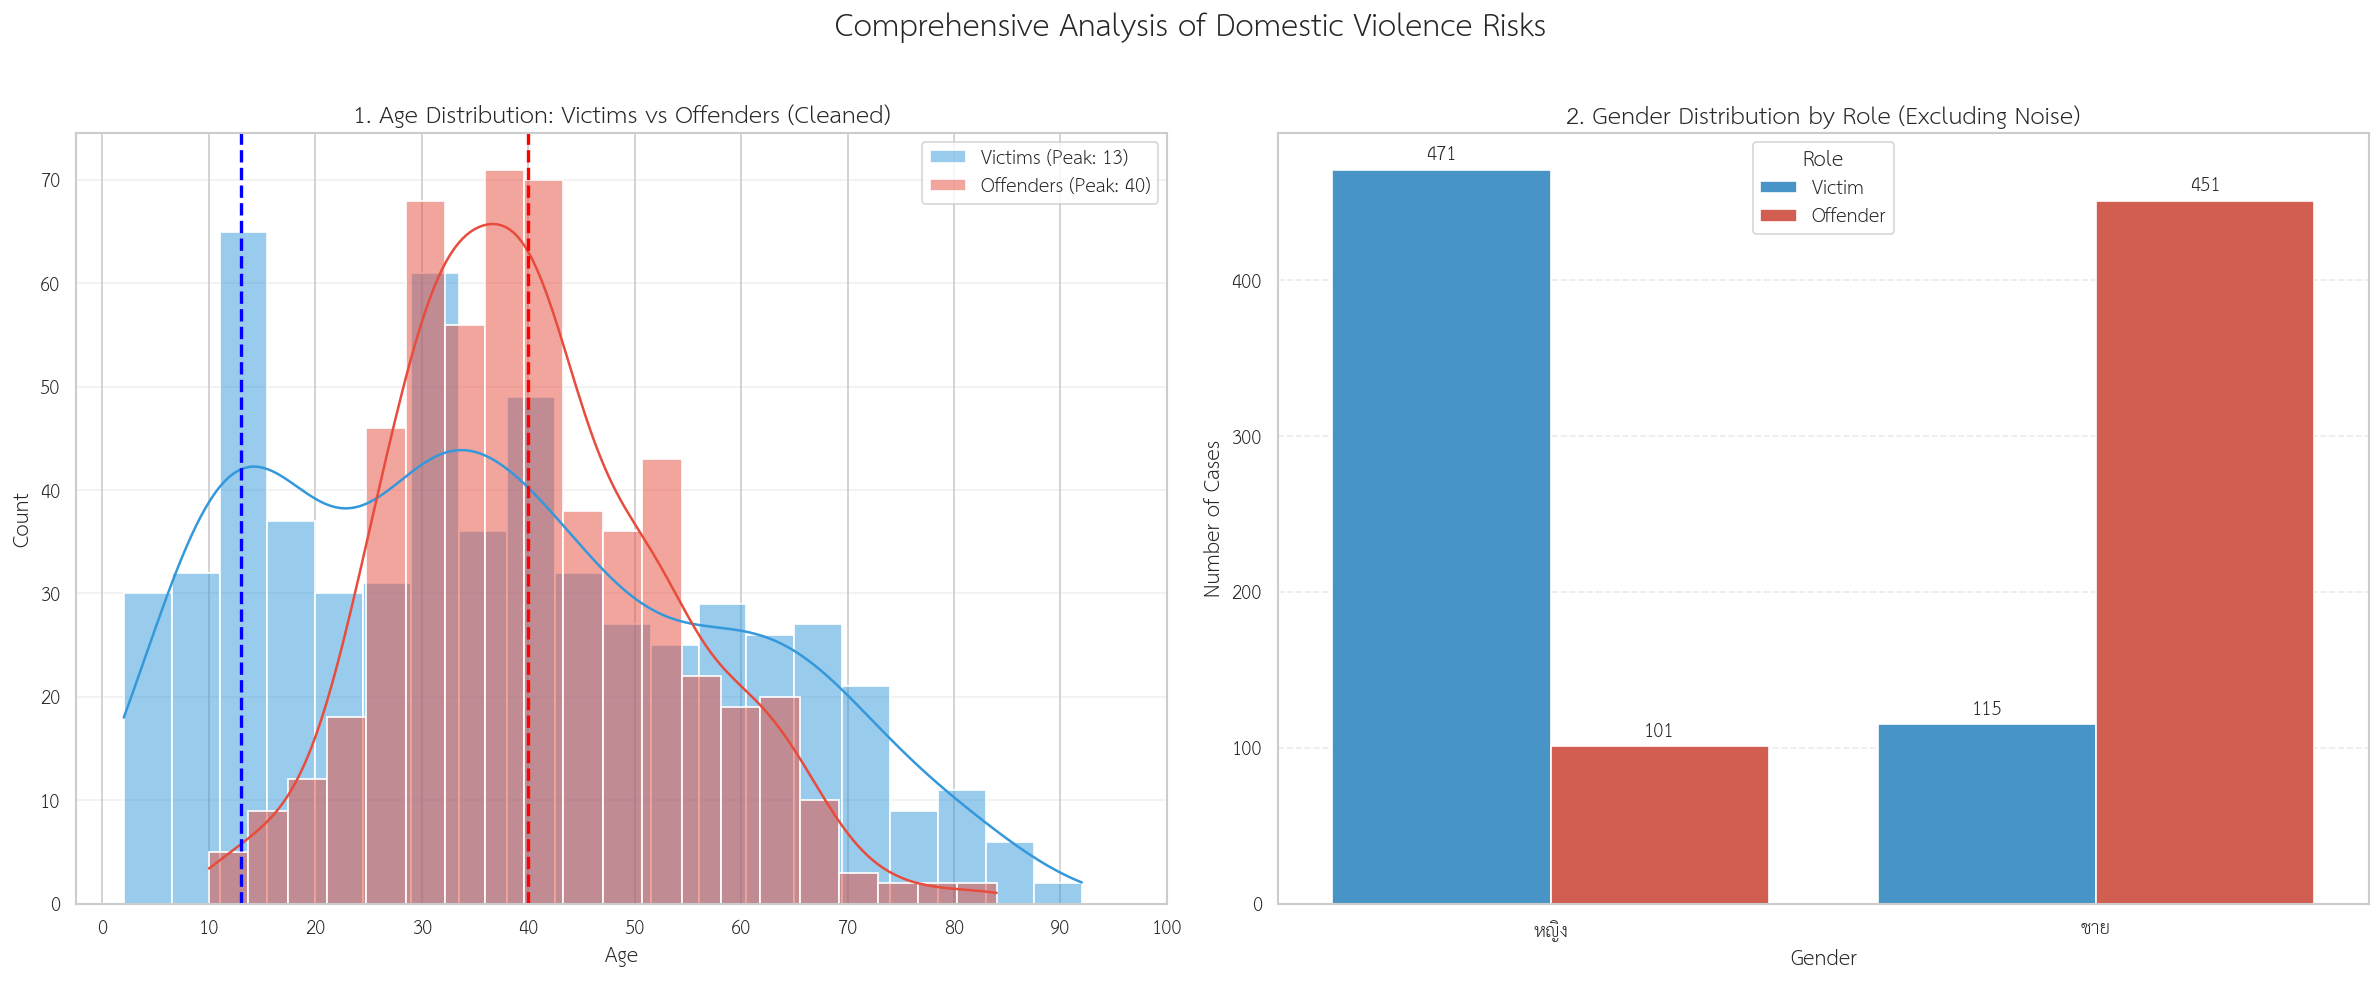

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. การทำความสะอาดข้อมูล  ---
# ลบข้อมูลซ้ำออกจากทุก Dataset
df_v_clean = df_victim.drop_duplicates()
df_o_clean = df_offender.drop_duplicates()

# กรองเอาเฉพาะ 'หญิง' และ 'ชาย' (ตัด Noise 0.17% ออก)
df_v_clean = df_v_clean[df_v_clean['Gender'].isin(['หญิง', 'ชาย'])]
df_o_clean = df_o_clean[df_o_clean['Gender'].isin(['หญิง', 'ชาย'])]

# --- 2. เตรียมข้อมูลสำหรับกราฟแท่ง (Gender) ---
v_gender = df_v_clean['Gender'].value_counts().reset_index()
v_gender.columns = ['Gender', 'count']
v_gender['Role'] = 'Victim'

o_gender = df_o_clean['Gender'].value_counts().reset_index()
o_gender.columns = ['Gender', 'count']
o_gender['Role'] = 'Offender'

gender_comp = pd.concat([v_gender, o_gender])

# --- 3. สร้าง Visualization แบบ 1 แถว 2 คอลัมน์ ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# --- [ฝั่งซ้าย: ax1] Age Distribution (ใช้ข้อมูลที่ Clean แล้ว) ---
# คำนวณ Mode จากข้อมูลที่คลีนแล้ว
mode_v = df_v_clean['Age'].mode()[0]
mode_o = df_o_clean['Age'].mode()[0]

sns.histplot(df_v_clean['Age'], bins=20, kde=True, color="#3498db",
             label=f'Victims (Peak: {mode_v})', alpha=0.5, ax=ax1)
sns.histplot(df_o_clean['Age'], bins=20, kde=True, color="#e74c3c",
             label=f'Offenders (Peak: {mode_o})', alpha=0.5, ax=ax1)

ax1.axvline(mode_v, color='blue', linestyle='--', linewidth=2)
ax1.axvline(mode_o, color='red', linestyle='--', linewidth=2)
ax1.set_title("1. Age Distribution: Victims vs Offenders (Cleaned)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Age")
ax1.set_xticks(range(0, 101, 10))
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# --- [ฝั่งขวา: ax2] Gender Distribution (ใช้ข้อมูลที่ Clean แล้ว) ---
sns.barplot(data=gender_comp, x='Gender', y='count', hue='Role',
            palette=['#3498db', '#e74c3c'], ax=ax2)

for container in ax2.containers:
    ax2.bar_label(container, fmt='%d', padding=3, fontsize=11, fontweight='bold')

ax2.set_title("2. Gender Distribution by Role (Excluding Noise)", fontsize=14, fontweight='bold')
ax2.set_ylabel("Number of Cases")
ax2.grid(axis='y', linestyle='--', alpha=0.4)

# ใส่หัวข้อใหญ่
plt.suptitle("Comprehensive Analysis of Domestic Violence Risks", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# เช็กค่า Mode ของผู้กระทำหลังจาก Clean แล้ว
print(df_o_clean['Age'].mode())

# ดู 5 อันดับแรกของอายุที่ก่อเหตุบ่อยที่สุด
print(df_o_clean['Age'].value_counts().head(5))

0    40
Name: Age, dtype: int64
Age
40    23
33    22
38    22
31    20
41    20
Name: count, dtype: int64


###**ใครเสี่ยงที่สุด? (Who is at risk?)**
1.**Age Gap**: พบความเหลื่อมล้ำของช่วงวัยที่ชัดเจน เหยื่อมีจุด Peak ที่อายุ 13 ปี (เด็ก/เยาวชน) ขณะที่ผู้กระทำมีจุด Peak ที่ 38 ปี (วัยทำงาน) ช่องว่างระหว่างวัยที่ต่างกันถึง 25 ปี สะท้อนถึงปัญหาเชิงอำนาจในครอบครัว

2.**Gender Pattern**: ผู้หญิงมีโอกาสตกเป็นเหยื่อสูงกว่าผู้ชายถึง 4 เท่า (479 vs 117) ในขณะที่ผู้ชายมีแนวโน้มเป็นผู้กระทำมากกว่าผู้หญิงในสัดส่วนที่ใกล้เคียงกัน



###**Actionable Proposal:**

**มาตรการป้องกัน**: ควรมุ่งเน้นไปที่ระบบการแจ้งเหตุในโรงเรียนมัธยมต้น เนื่องจากเป็นจุด Peak ของเหยื่อ และพัฒนาช่องทางแจ้งเหตุแบบลับสำหรับผู้หญิงในชุมชน

**กลุ่มเป้าหมาย**: ออกแบบแคมเปญลดความรุนแรงที่มุ่งเป้าไปที่ "ผู้ชายวัยทำงาน" เพื่อปรับทัศนคติและการจัดการอารมณ์

--------------------------------------------------------------------------------
####**จากการทำ Data Cleaning โดยการลบข้อมูลซ้ำ (Duplicates) ออก พบว่าจุด Peak หรืออายุที่ผู้กระทำผิดก่อเหตุบ่อยที่สุดมีการเปลี่ยนแปลงเล็กน้อยจากข้อมูลดิบ ซึ่งแสดงให้เห็นถึงความสำคัญของการทำความสะอาดข้อมูลก่อนการวิเคราะห์ ทำให้เราได้ Insight ที่แม่นยำว่ากลุ่มอายุวิกฤตที่แท้จริงคือช่วงอายุ [40] ปี และจำนวนของกลุ่มเพศที่วิกฤตที่แท้จริง คือ เพศหญิง[471] เพศชาย[115]**

--------------------------------------------------------------------------------
###📍⏰ ข้อ 2 — เกิดที่ไหน เมื่อไหร่? (Where & When?)
📊 จงสร้าง Visualization ที่แสดง รูปแบบการกระจายตัวของเหตุการณ์ความรุนแรงในครอบครัว

โดยพิจารณาทั้ง
มิติของพื้นที่
มิติของช่วงเวลา
เพื่อให้สามารถมองเห็นว่า เหตุการณ์เหล่านี้เกิดขึ้นที่ใดบ่อยที่สุด และเกิดขึ้นในช่วงเวลาใดมากที่สุด

ผลงานควรช่วยระบุให้เห็นว่า พื้นที่หรือช่วงเวลาใดคือ “จุดวิกฤต (Hotspot)”

ซึ่งอาจต้องได้รับ การจัดสรรทรัพยากร การเฝ้าระวัง หรือมาตรการป้องกันเพิ่มเติมจากหน่วยงานที่เกี่ยวข้อง

In [ ]:
# ลบข้อมูลซ้ำ (เพื่อความแม่นยำของ Hotspot)
df_case_clean = df_case.drop_duplicates()

# ตรวจสอบค่าในมิติต่างๆ
print(df_case_clean['Period'].value_counts())
print(df_case_clean['Locale'].value_counts())

Period
12:01 – 18:00    309
06:01 – 12:00    247
18:01 – 00:00    237
00:01 – 06:00     68
Name: count, dtype: int64
Locale
สถานที่ส่วนบุคคล    757
สถานที่สาธารณะ       75
สถานที่ทำงาน         19
สถานศึกษา            10
Name: count, dtype: int64


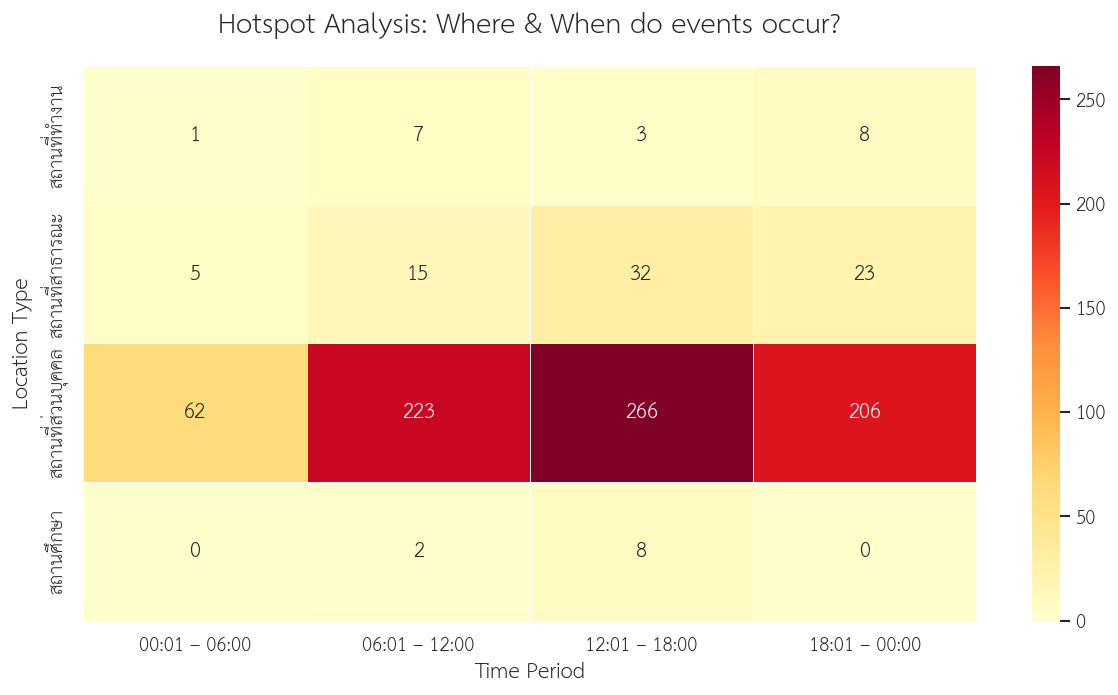

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. เตรียมข้อมูล Heatmap: สถานที่ vs ช่วงเวลา
# เราจะสร้างตาราง Pivot Table เพื่อดูความหนาแน่น
heatmap_data = df_case_clean.pivot_table(index='Locale',
                                         columns='Period',
                                         values='Regional',
                                         aggfunc='count').fillna(0)

# เรียงลำดับคอลัมน์เวลาให้สวยงาม (ถ้าจำเป็น)
time_order = ['00:01 – 06:00', '06:01 – 12:00', '12:01 – 18:00', '18:01 – 00:00']
heatmap_data = heatmap_data.reindex(columns=time_order)

# 2. สร้าง Visualization
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=.5)

plt.title("Hotspot Analysis: Where & When do events occur?", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Time Period", fontsize=12)
plt.ylabel("Location Type", fontsize=12)

plt.show()

#**Hotspot Insight:**
1.The Prime Target: "สถานที่ส่วนบุคคล" ในช่วงเวลา 12:01 – 18.00 น.สูงถึง 266 ราย เคส รองลงมาคือช่วง  06:01 – 12:00 (เช้า) ที่ 223 เคส

2.สถานที่วิกฤต (Primary Location): "สถานที่ส่วนบุคคล" ครองแชมป์ในทุกช่วงเวลา โดยมีตัวเลขโดดเดี่ยวจากสถานที่อื่นอย่างเห็นได้ชัด

3.ข้อสังเกตที่สำคัญ (The Surprise Insight): ข้อมูลชี้ให้เห็นว่าความรุนแรงในครอบครัวไม่ได้เกิดมากที่สุดในตอนกลางคืนตามความเข้าใจทั่วไป แต่กลับ หนาแน่นในช่วงกลางวัน (06:00 - 18:00 น.) ซึ่งรวมกันแล้วมากกว่า 50% ของเหตุการณ์ทั้งหมด


#**ข้อเสนอแนะเชิงนโยบาย (Actionable Proposal)**

การจัดสรรทรัพยากร (Daytime Resource Allocation): หน่วยงานที่เกี่ยวข้องควรเน้นการทำงานเชิงรุกใน ช่วงเวลากลางวัน เช่น การเพิ่มกำลังเจ้าหน้าที่รับแจ้งเหตุและทีมเคลื่อนที่เร็วในช่วงเวลาทำการ (08:00 - 18:00 น.) เพราะเป็นช่วงที่มีสถิติสูงสุด

การเข้าถึงพื้นที่ส่วนบุคคล (Home-Based Protection): เนื่องจากเหตุเกิดในบ้านเป็นหลัก มาตรการป้องกันควรเน้นไปที่การสร้างเครือข่าย "อาสาสมัครชุมชน" หรือ "อสม." ที่สามารถเข้าถึงและสังเกตการณ์บ้านเรือนในละแวกนั้นได้ในช่วงกลางวันที่ผู้คนส่วนใหญ่ออกไปทำงาน

กลยุทธ์การแจ้งเหตุ: ควรประชาสัมพันธ์ช่องทางการแจ้งเหตุที่เงียบและปลอดภัย (เช่น LINE หรือ App) เพื่อให้เหยื่อที่อยู่ในบ้านสามารถแจ้งเหตุได้ในช่วงกลางวันที่ผู้กระทำอาจอยู่ด้วยกันในพื้นที่ส่วนตัว

--------------------------------------------------------------------------------

#**ข้อ 3 — อะไรคือสัญญาณเตือน? (What triggers violence?)**
📊 จากข้อมูลเกี่ยวกับ ปัจจัยเสี่ยงของผู้กระทำความรุนแรงในครอบครัว

จงสร้าง Visualization ที่ช่วยให้ผู้กำหนดนโยบายสามารถเข้าใจได้อย่างรวดเร็วว่า
ปัจจัยใดควรได้รับความสำคัญในการป้องกันก่อน
และ เหตุใดปัจจัยนั้นจึงมีความสำคัญต่อการเกิดเหตุความรุนแรง
ผลงานควรสามารถสื่อสารให้เห็น ลำดับความสำคัญของปัจจัยเสี่ยง และช่วยให้ผู้อ่านเข้าใจว่า
หากต้องออกแบบมาตรการป้องกัน ควรเริ่มต้นจากปัจจัยใดก่อน ผ่านการนำเสนอข้อมูลที่ชัดเจนและเข้าใจง่ายผ่าน Visualization

In [ ]:
# 1. รายชื่อคอลัมน์ที่เป็นปัจจัยเสี่ยง
factors = ['Alcohol', 'Drug', 'Authoritative', 'Rage', 'Jealous',
           'Divorce', 'Health Problem', 'Mental Problem',
           'Gambling Addict', 'Economics Stress']

# 2. นับจำนวน "ใช่" ในแต่ละปัจจัย
factor_counts = {}
for f in factors:
    count = (df_o_clean[f] == 'ใช่').sum()
    factor_counts[f] = count

# 3. แปลงเป็น DataFrame และคำนวณเป็นเปอร์เซ็นต์
df_factors = pd.DataFrame(list(factor_counts.items()), columns=['Factor', 'Count'])
df_factors['Percentage'] = (df_factors['Count'] / len(df_o_clean)) * 100
df_factors = df_factors.sort_values(by='Count', ascending=False)

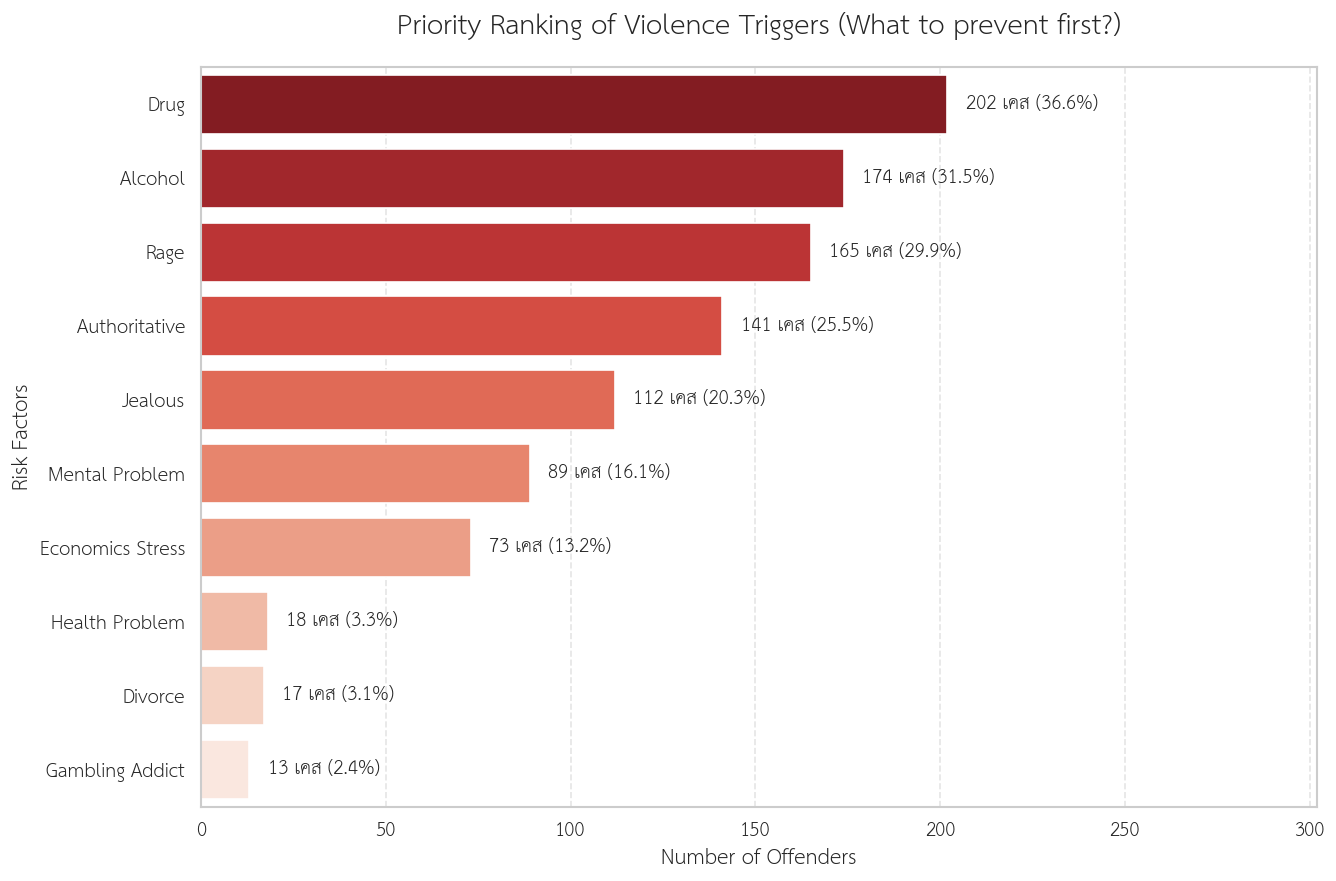

In [ ]:
plt.figure(figsize=(12, 8))
# ใช้สีไล่เฉด (Palette) เพื่อเน้นอันดับต้นๆ ให้เด่นชัด
ax = sns.barplot(data=df_factors, x='Count', y='Factor', palette='Reds_r')

# ใส่ตัวเลขจำนวนและเปอร์เซ็นต์บนหัวแท่ง
for i, p in enumerate(ax.patches):
    percentage = df_factors.iloc[i]['Percentage']
    ax.annotate(f"{int(p.get_width())} เคส ({percentage:.1f}%)",
                (p.get_width() + 5, p.get_y() + p.get_height()/2),
                va='center', fontsize=11, fontweight='bold')

plt.title("Priority Ranking of Violence Triggers (What to prevent first?)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Number of Offenders", fontsize=12)
plt.ylabel("Risk Factors", fontsize=12)
plt.xlim(0, df_factors['Count'].max() + 100) # เผื่อที่สำหรับตัวเลข
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

###**สรุปผลการวิเคราะห์ (Key Insights):**

1.ปัจจัยกระตุ้นหลัก (The Top Triggers): สัญญาณเตือนที่อันดับ 1 และ 2 คือ "ยาเสพติด (Drug)" และ "สุรา (Alcohol)"
ซึ่งรวมกันเป็นปัจจัยกระตุ้นในสัดส่วนที่สูงมาก (มากกว่า 60% ของเคสทั้งหมด)

2.ปัจจัยด้านอารมณ์: "การบันดาลโทสะ (Rage)" ตามมาเป็นอันดับ 3 (29.9%) ซึ่งสะท้อนว่าความรุนแรงมักเกิดขึ้นเมื่อมีสารกระตุ้นร่วมกับสภาวะอารมณ์ที่ไม่มั่นคง

3.ข้อสังเกตเพิ่มเติม: ปัจจัยด้านเศรษฐกิจ (Economics Stress) และปัญหาสุขภาพจิต (Mental Problem) แม้จะมีสัดส่วนรองลงมา แต่ก็เป็นปัจจัยพื้นฐานที่อาจนำไปสู่การดื่มสุราหรือใช้ยาเสพติดได้


###**ข้อเสนอแนะเชิงนโยบาย (Actionable Proposal for Policymakers):**

มาตรการ "ตัดวงจร" (Primary Prevention): เนื่องจากยาเสพติดและสุราคือปัจจัยหลัก รัฐควรออกแบบมาตรการเชิงรุกในการ บำบัดผู้ติดสารเสพติดและสุราในชุมชน โดยเฉพาะในพื้นที่ "Hotspot" (สถานที่ส่วนบุคคล) **ที่เราพบในข้อ 2**

โปรแกรมจัดการอารมณ์ (Secondary Prevention): ควรมีการส่งเสริมหลักสูตร "Anger Management" หรือการสื่อสารเชิงบวกในครอบครัว โดยมุ่งเป้าไปที่กลุ่มผู้ชายวัยทำงาน (อายุ 30-45 ปี) ซึ่งเป็นกลุ่มหลัก**ที่พบในข้อ 1**

การบูรณาการความช่วยเหลือ: หากพบครอบครัวที่มีปัญหาเศรษฐกิจร่วมกับมีการใช้สุรา หน่วยงานควรเข้าแทรกแซงทันที (Intervene) ก่อนที่จะพัฒนาไปสู่ความรุนแรง เพราะนี่คือ "สัญญาณเตือนภัยล่วงหน้า" (Early Warning Signal) ที่ชัดเจนที่สุดจากข้อมูล



---


#**ภาพรวมจากข้อมูลทั้ง 3 ข้อ**

#**สรุปภาพรวมการวิเคราะห์ (Executive Summary)**
###จากรูปแบบข้อมูล พบว่ากลุ่มผู้กระทำที่พบบ่อยคือผู้ชายวัยทำงาน (38–40 ปี) ที่มีปัจจัยเสี่ยงจากยาเสพติดและสุราขณะที่กลุ่มผู้ถูกกระทำมักเป็นผู้หญิงและเด็ก (อายุประมาณ 13 ปี)เหตุการณ์ส่วนใหญ่เกิดในสถานที่ส่วนบุคคลและกระจุกตัวในช่วงเวลากลางวัน


---


###อย่างไรก็ตามความสัมพันธ์ดังกล่าวเป็นการวิเคราะห์เชิงสังเกตและไม่สามารถสรุปเชิงเหตุและผลโดยตรงได้ แต่สามารถใช้เป็นแนวทางในการกำหนดมาตรการเชิงป้องกันได้


---

### ดังนั้น มาตรการที่มีศักยภาพสูงสุดคือการมุ่งเน้นการบำบัดสารเสพติดควบคู่กับการเฝ้าระวังในชุมชนช่วงเวลากลางวัน ซึ่งครอบคลุมบริบทของเหตุการณ์ส่วนใหญ่และสามารถลดความเสี่ยงได้ในวงกว้าง